### Python implementation of Leen's Network (minimal)

This notebook is an example of code implementation of Leen's algorithm to find principal components. This notebook focuses on the core algorithm of the Leen's minimal network, which is a simplified version of the full Leen's network. The minimal network is designed to capture the essential features of the algorithm while accurately capturing all the PCs of the input data. 

The math derivations are below:

$$
\mathbf{y} = \mathbf{w} \mathbf{x}
$$

$$
S = (I + q) y
$$

$$
\Delta W_i = \eta_w (\langle x s_i \rangle - \gamma_w \langle y_i^2 \rangle w_i)
$$

$$
\Delta q_{ik} = \eta_q (- \langle y_i^2 + y_k^2 \rangle * q_{ik} - C\langle y_i y_k \rangle), q_{ii} = 0
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hebbian.models import LeenMinimalPCA, LeenCompletePCA

### Leen's model, complete:

$$
\mathbf{y_{t+1} = W(t) x_t + q(t) y_t}
$$

Forward weights update:
$$
\Delta W = \eta_w (\langle y x^\top \rangle - diag(yy^\top) W)
$$

The lateral connection update, with activity dependent way:

$$
\Delta q_{ik} = \eta_q (\langle y_i^2 + y_k^2 \rangle ) q_{ik} - C(\langle y_i y_k \rangle)
$$




In [2]:
from hebbian.utils import generate_covariance_matrix, Y_aligned_training_testing, instantiate_samples_by_cov, training_testing

### Helper functions:

- PCA alignment helpers
- Data generation helpers
- Training and evaluation helpers


### Practical Example: 3 Neurons test case
Create an input matrix X with information about the eigenvalues and eigenvectors of the covariance matrix of the data.

In [7]:
d = 3
m = 3
n_samples = 10001
X_seed = 0

# get /sigma
eigenvalues = np.array([10.0,7.6, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples = instantiate_samples_by_cov(Sigma, d, m, seed=X_seed, n_samples=n_samples)
# model = LeenMinimalPCA(d, m, eta_w=2e-3, eta_q=1.5e-1, C=1.8,
#                        ema_alpha=-1.1,
#                        clip_q_spectral=-1.9, seed=None)



In [4]:
# --- Step 1: Define the desired data structure ---
input_dimension = 10
num_principal_components = 3
principal_eigenvalues = [20.0, 2.0, 0.2] # The "strength" of our 3 PCs
# Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")
# samples = instantiate_samples_by_cov(Sigma, d, m, seed=X_seed, n_samples=n_samples)


# model = LeenMinimalPCA(d, m, eta_w=2e-3, eta_q=1.5e-1, C=1.8,
#                        ema_alpha=-1.1,
#                        clip_q_spectral=-1.9, seed=None)

In [11]:
# 3.1 Complete mode
# model = LeenCompletePCA(d, m, eta_w=1e-5, eta_q=9e-4, C=2.0,
#                        ema_alpha=0.1, symmetrize_q=True, seed=None, settling_steps=10, noise_level=0.01)

# 3.2 Minimal mode
# training_testing(model, X, number_of_samples, m)
model_paras = {
    'input_size': d,
    'output_size': m,
    'eta_w': 1e-4,
    'eta_q': 1e-3,
    'C': 1.5,
    'ema_alpha': 0.1,
    'symmetrize_q': True,
    'seed': None,
    # 'noise_level': 0.01,
    # 'settling_steps': 10,
}
# Y_aligned_training_testing(model, X, batch_size=1, alignment = "corr")
# Y_aligned_training_testing_online(model, X, batch_size=1, alignment = "corr")
# averaged_training_testing_W(LeenCompletePCA, model_paras=model_paras, X=X, runs=10, batch_size=100, graph=True)
# averaged_training_testing_Y(LeenCompletePCA, model_paras=model_paras, X=X, runs=10, batch_size=1, graph=True)


run  1
step    0 | order = [0 2 1] | best|corr|= [0.924 0.234 0.917]
step 1000 | order = [0 2 1] | best|corr|= [0.945 0.189 0.974]
step 2000 | order = [0 2 1] | best|corr|= [0.916 0.145 0.983]
step 3000 | order = [2 0 1] | best|corr|= [0.024 0.974 0.986]
step 4000 | order = [2 0 1] | best|corr|= [0.01  0.957 0.992]
step 5000 | order = [2 0 1] | best|corr|= [0.003 0.941 0.989]
step 6000 | order = [2 0 1] | best|corr|= [0.004 0.934 0.989]
step 7000 | order = [2 0 1] | best|corr|= [0.001 0.933 0.989]
step 8000 | order = [2 0 1] | best|corr|= [0.004 0.929 0.989]
step 9000 | order = [2 0 1] | best|corr|= [0.004 0.93  0.987]
step 10000 | order = [2 0 1] | best|corr|= [0.007 0.932 0.987]


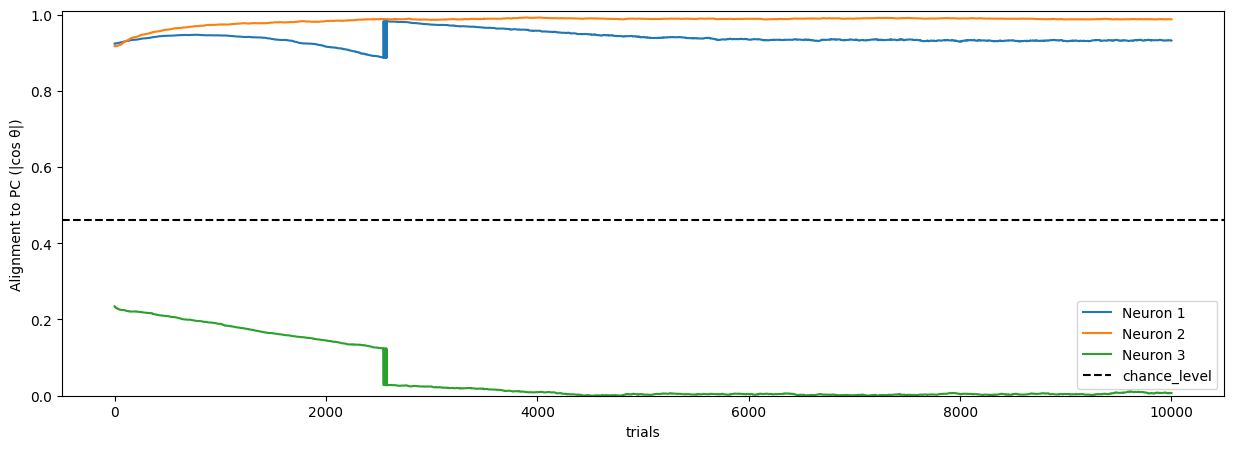

run  2
step    0 | order = [2 0 1] | best|corr|= [0.948 0.837 0.547]
step 1000 | order = [2 0 1] | best|corr|= [0.943 0.942 0.708]
step 2000 | order = [2 0 1] | best|corr|= [0.973 0.97  0.872]
step 3000 | order = [2 0 1] | best|corr|= [0.993 0.983 0.952]
step 4000 | order = [2 0 1] | best|corr|= [0.998 0.985 0.976]
step 5000 | order = [2 0 1] | best|corr|= [1.    0.988 0.983]
step 6000 | order = [2 0 1] | best|corr|= [1.    0.988 0.986]
step 7000 | order = [2 0 1] | best|corr|= [1.    0.988 0.987]
step 8000 | order = [2 0 1] | best|corr|= [1.    0.988 0.99 ]
step 9000 | order = [2 0 1] | best|corr|= [1.    0.99  0.989]
step 10000 | order = [2 0 1] | best|corr|= [1.    0.991 0.988]


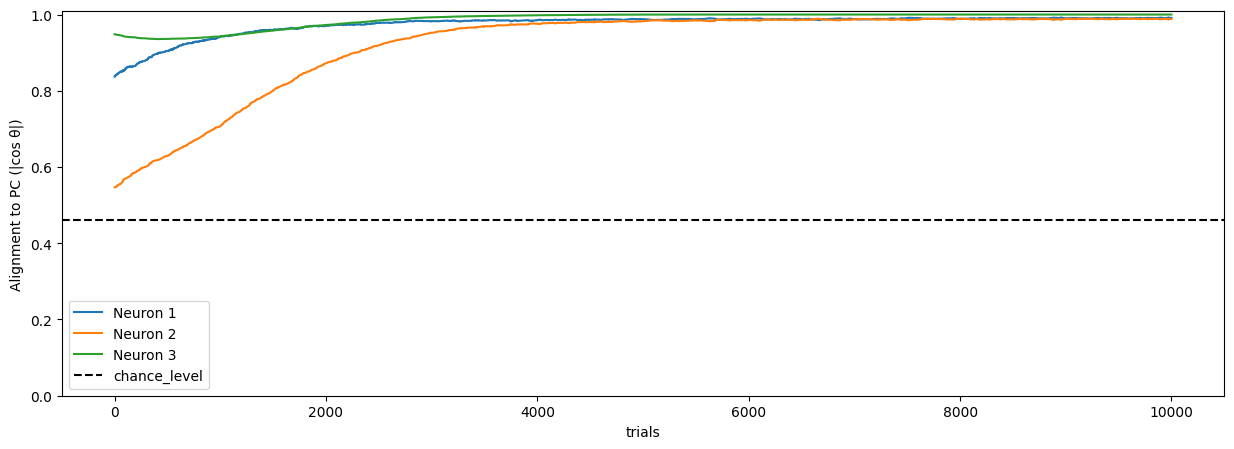

<Figure size 640x480 with 0 Axes>

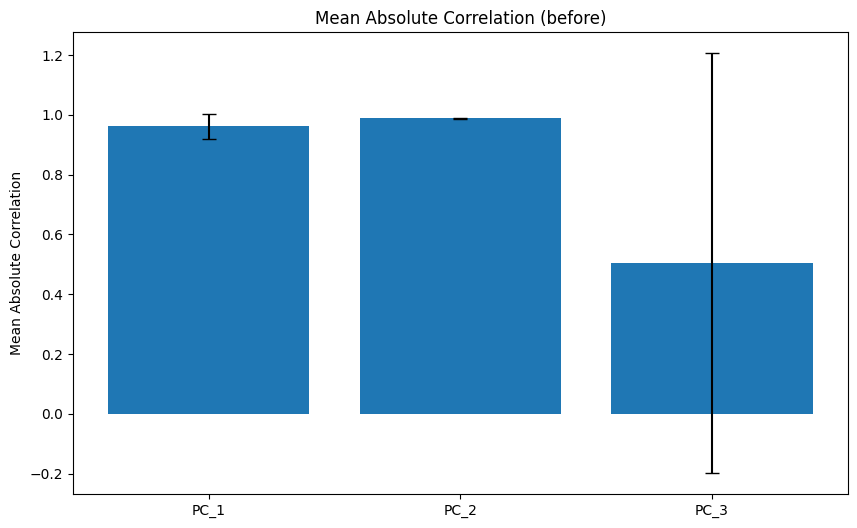

In [12]:
model = LeenMinimalPCA(**model_paras)
X = samples
training_testing(model, X, m, runs=2)